In [1]:
library(here)

knitr::opts_chunk$set(echo = TRUE)
options(box.path = here())

box::use(
  r / load
)
box::reload(load)

library(tidyverse)
library(texreg)
library(ggeffects)
library(ggpubr)

library(lme4)
library(marginaleffects)
library(sjstats)
library(slider)

theme_set(theme_minimal())


here() starts at /Users/lukas/git/ytpop
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors
Version:  1.39.4
Date:     2024-07-23
Author:   Philip Leifeld (University of Manchester)

Consider submitting praise using the praise or praise_interactive functions.
Please cite the JSS article in your publications -- see citation("texreg").

Attaching package: ‘texr

In [2]:
channels <- load$channels()
videos <- load$videos(filtered = TRUE) |> select(-c(channel, video_was_live))
sentences <- load$sentences(filtered = TRUE)
popbert <- load$popbert(filtered = TRUE)

df_sents <- sentences |>
  left_join(popbert, by = "sentence_id") |>
  group_by(video_id) |>
  summarize(
    n_sents = n(),
    elite = mean(elite),
    pplcentr = mean(pplcentr)
  ) 

In [3]:
centered <- function(x) (x - mean(x))
z_transform <- function(x) as.vector(scale(x))

df <- channels |>
  left_join(videos, by = "channel_id") |>
  left_join(df_sents, by = "video_id") |>
  mutate(
    channel = as_factor(channel)
  )

df <- df |> 
  # filter(video_datetime_upload > "2020-10-01") |> 
  mutate(
    released_at = video_datetime_upload |> lubridate::floor_date(unit="month") |> format("%Y-%m"),
    released_at = released_at |> factor(levels=sort(unique(released_at)), ordered=TRUE),
    released_year = video_datetime_upload |> lubridate::floor_date(unit="year") |> format("%Y")
  ) |> 
  filter(channel != "FDP") |>
  mutate(
    channel = channel |> fct_drop(),
    log_video_likes = sqrt(video_likes),
    log_video_views = log(1 + video_views),
    likes_per_view = video_likes / video_views,
    video_duration = log(video_duration),
    n_sents = log(n_sents),
    # elite = centered(elite),
    # pplcentr = centered(pplcentr),
  ) |> 
  arrange(channel, video_datetime_upload) |> 
  group_by(channel) |> 
  mutate(
    channel_rolling_views = slider::slide_index_dbl(
      log_video_views,
      .i = video_datetime_upload,
      .f = ~mean(.x, na.rm=T),
      .before = lubridate::weeks(12)
    )
  ) |> ungroup()

In [4]:
df |> filter(channel == "SPD") |> arrange(desc(video_views)) |> slice_head(n=100) |> View()

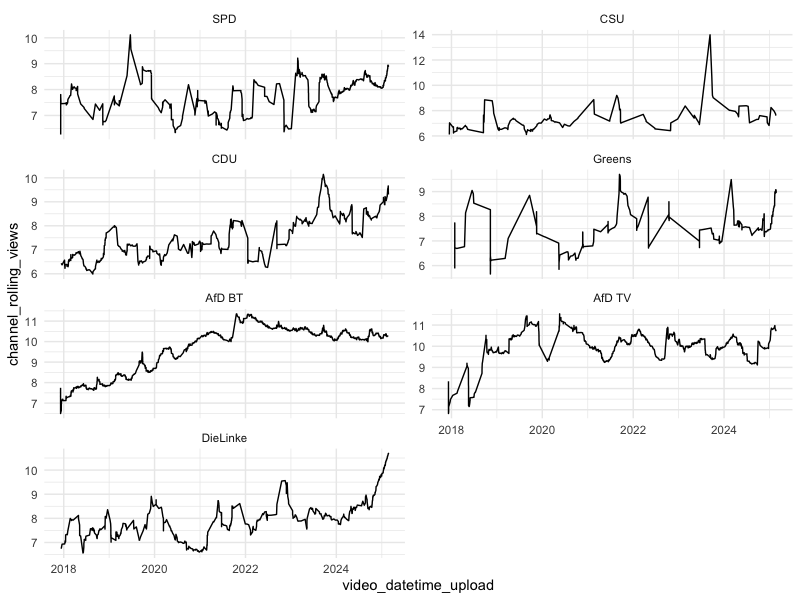

In [5]:
ggplot(df, aes(x=video_datetime_upload, y=channel_rolling_views)) +
  geom_line() +
  facet_wrap(~channel, ncol=2, scales="free_y")

# Models


## Video Views

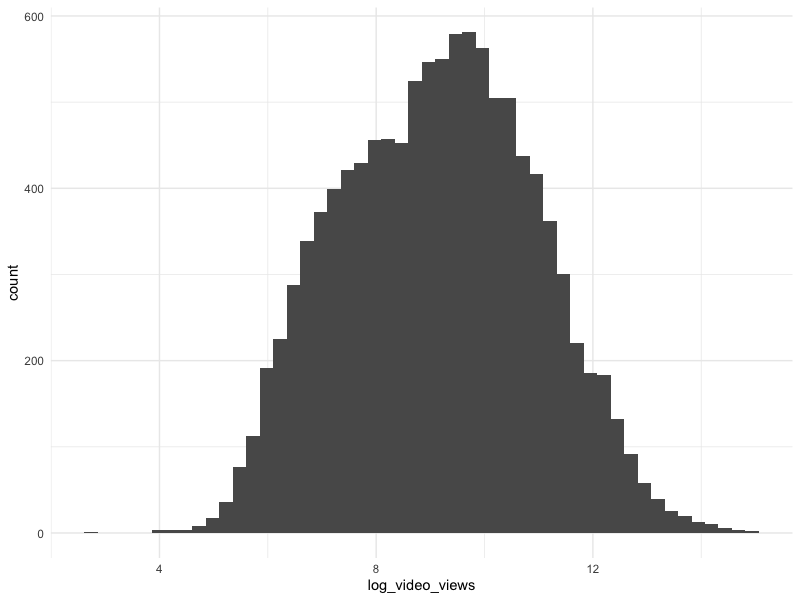

In [6]:
ggplot(df, aes(log_video_views)) +
  geom_histogram(bins=50)

### Elite Models

In [36]:
model <- lme4::lmer(
  formula = log_video_views ~ 1 + elite + n_sents + released_at + (1 + elite | channel),
  data = df
)

In [37]:
performance::icc(model)

# Intraclass Correlation Coefficient

    Adjusted ICC: 0.365
  Unadjusted ICC: 0.285

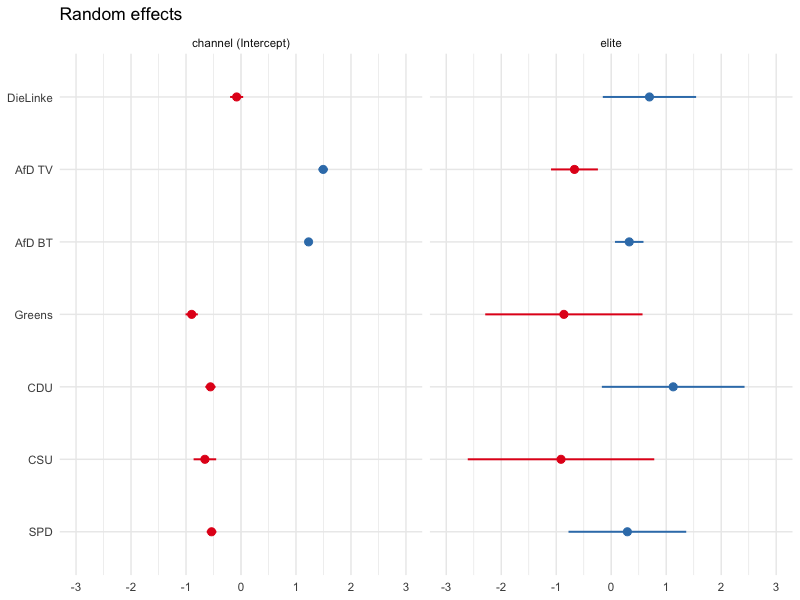

In [38]:
sjPlot::plot_model(model, type="re")

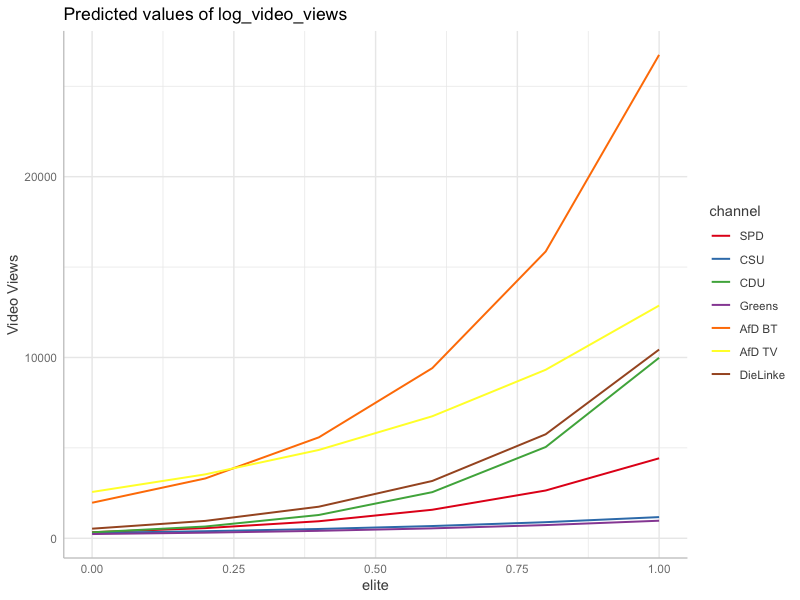

In [45]:
preds <- ggpredict(
  model,
  terms = c("elite", "channel"),
  type="random",
  margin="empirical"
)
preds$predicted <- exp(preds$predicted) - 1

plot(preds, show_ci = F) + labs(y="Video Views")

## Pplcentr model

In [23]:
model <- lme4::lmer(
  formula = log_video_views ~ 1 + pplcentr + n_sents + released_at + (1 + pplcentr | channel),
  data = df
)

In [24]:
performance::icc(model)

# Intraclass Correlation Coefficient

    Adjusted ICC: 0.412
  Unadjusted ICC: 0.335

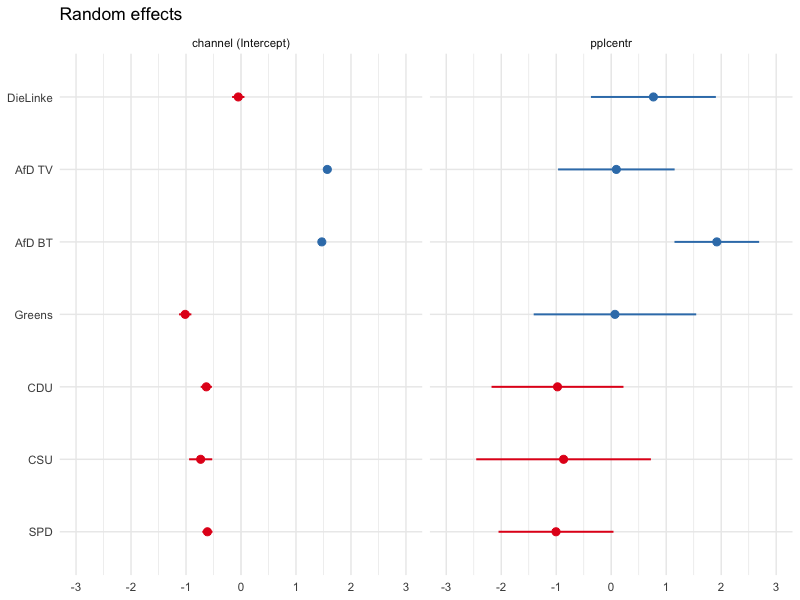

In [25]:
sjPlot::plot_model(model, type="re")

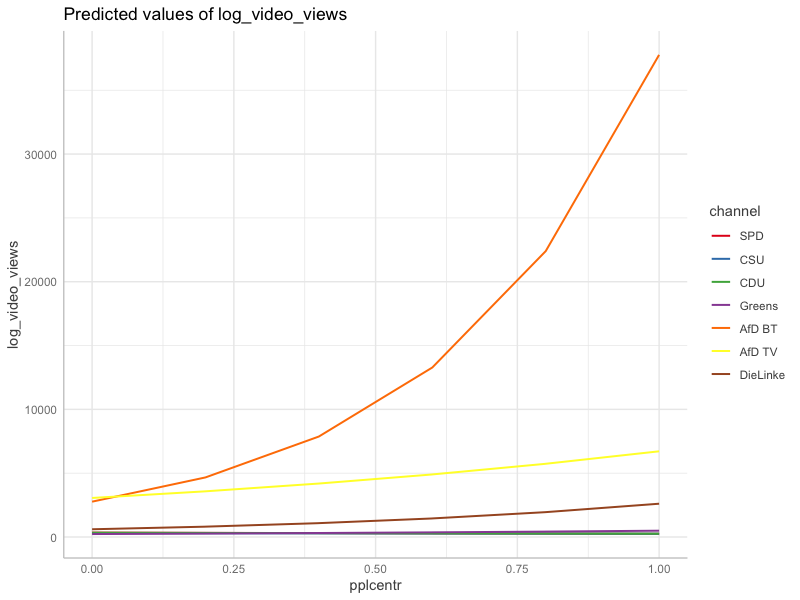

In [34]:
preds <- ggpredict(
  model,
  terms = c("pplcentr", "channel"),
  type="random",
  margin="empirical"
)
preds$predicted <- exp(preds$predicted)

plot(preds, show_ci = F)